In [1]:
# ===========================================
# BEBs Morphotypes Predictor
# ===========================================

# Step 0: Import libraries
import os
import pandas as pd
import numpy as np

# Set working directory where the Excel file is stored
directory = r"C:\Users\mgaz4900\OneDrive - The University of Sydney (Staff)\Chapter-4 Predicting BEBs Morphosates\Codes\BEBs Morphostate Index"
os.chdir(directory)

# Step 1: Load data

df = pd.read_excel(
    "Data_BEBs.xlsx",
    sheet_name='data_calibration'
)

# Preview first rows to confirm data loaded correctly
df.head()

# ===========================================
# Step 2: Define index calculation functions
# ===========================================

# ------------------------
# 2a. Parameter A: Swell–Entrance Alignment (SEA)
# ------------------------
# Measures alignment between dominant swell direction and estuary/bay entrance
# High values (~1) indicate well-aligned entrance-swell orientation
def compute_Parameter_A(df):
    # Calculate difference in degrees
    df["Delta_theta1"] = abs(df["Swell Direction (SD)"] - df["Entrance Orientation (EO)"])
    # Adjust differences greater than 180 degrees
    df["Delta_theta1"] = np.where(df["Delta_theta1"] > 180, 360 - df["Delta_theta1"], df["Delta_theta1"])
    # Compute SEAI normalized between 0–1
    df["SEA"] = (1 + np.cos(np.radians(df["Delta_theta1"]))) / 2
    df["SEA"] = df["SEA"].round(2)
    
    # Classification for interpretation
    def classify_sea(val):
        if val < 0.35: return "Poor Alignment"
        elif val <= 0.6: return "Moderate Alignment"
        else: return "Good Alignment"
    
    df["SEAIm_Class"] = df["SEA"].apply(classify_sea)
    return df

# ------------------------
# 2b. Parameter B: Beach-Entrance Alignment (BEA)
# ------------------------
# Measures alignment between entrance direction and beach orientation
def compute_Parameter_B(df):
    df["Delta_theta2"] = abs(df["Entrance Orientation (EO)"] - df["Beach Orientation (BO)"])
    df["Delta_theta2"] = np.where(df["Delta_theta2"] > 180, 360 - df["Delta_theta2"], df["Delta_theta2"])
    df["BEA"] = (1 + np.cos(np.radians(df["Delta_theta2"]))) / 2
    df["BEA"] = df["BEA"].round(2)
    
    def classify_bea(val):
        if val < 0.35: return "Poor Alignment"
        elif val <= 0.6: return "Moderate Alignment"
        else: return "Good Alignment"
    
    df["EBAI_Class"] = df["BEA"].apply(classify_bea)
    return df

# ------------------------
# 2c. Parameter C: Integrated Coastal Sheltering (ICS)
# ------------------------
# Combines coastline straightness (CSI) and local barrier index (LBI)
def compute_Parameter_C(df):
    df["ICS_RAW"] = df["Actual Length (AL) (m)"] / df["Straight Length (SL) (m)"]
    ICS_min = 1
    ICS_max = 4
    df["ICS_normalized"] = (df["ICS_RAW"] - ICS_min) / (ICS_max - ICS_min)
    # Barrier effectiveness normalized 0–1
    df["LBI"] = df["Barrier Effectiveness"].round(2)
    df["ICS"] = ((df["LBI"] + df["ICS_normalized"]) / 2).round(2)
    return df


# ------------------------
# 2d. Parameter D: Mean Depth (MD)
# ------------------------
# Normalized mean depth
def compute_Parameter_D(df):
    ED_min = 2
    ED_max = 60
    df["MD"] = (df["Embayment Depth (ED) (m)"] - ED_min) / (ED_max - ED_min)
    return df


# ------------------------
# 2e. Parameter E: Entrance Width-to-Area Ratio (EWAR)
# ------------------------
# Indicates entrance openness relative to bay size
def compute_Parameter_E(df):
    EWAR_min = 0.04
    EWAR_max = 4.2
    df["EWARr"] = df["Entrance Width (EW) (km)"] / (df["Bay/Estuary Area (BA) (km2)"] ** 0.5)
    df["EWAR"] = (df["EWARr"] - EWAR_min) / (EWAR_max - EWAR_min)
    df["EWAR"] = df["EWAR"].round(2)
    
    def categorize_ewar(val):
        if val > 0.15: return "Wide"
        elif val > 0.10: return "Medium"
        elif val > 0.02: return "Narrow"
        else: return "Restricted"
    
    df["Entrance_Type"] = df["EWAR"].apply(categorize_ewar)
    return df


# ------------------------
# 2f. Parameter F: Fetch Adjusted Distance from Entrance (FADE)
# ------------------------
# Quantifies exposure based on distance from entrance normalized by fetch
def compute_Parameter_F(df):
    df["FADE"] = (df["BEBs Distance from the Entrance (m)"] / df["Longest Fetch (m)"]).round(2)
    
    def classify_fade(val):
        if val < 0.3: return "Close to the Entrance"
        elif val <= 0.6: return "Mid Bay/Estuary relative to the Entrance"
        else: return "Furthest from the Entrance"
    
    df["FADE_Class"] = df["FADE"].apply(classify_fade)
    return df


# ------------------------
# 2g. Parameter G: Swell Potentiality (SP)
# ------------------------
# Measures potential wave energy impacting beach
def compute_Parameter_G(df):
    SP_min = 0.10
    SP_max = 3.67
    df["SP"] = (df["Swell Height (SH) (m)"] - SP_min) / (SP_max - SP_min)
    return df


# ------------------------
# 2h. Morphostate Index & Classification
# ------------------------
# Combines all indices to assign a beach morphotype
def compute_morphotypes_predictor(df):
    intercept = 0.4752
    df["Morphotypes_Predictor_Score"] = (
        df["SEA"] * 0.1487 +
        df["BEA"] * 0.5137 +
        df["EWAR"] * 0.0010 +
        df["FADE"] * -0.9271 +
        df["MD"] * 0.0054 +
        df["ICS"] * -0.1124 +
        df["SP"] * 0.0183
    ) + intercept
    df["Morphotypes_Predictor_Score"] = df["Morphotypes_Predictor_Score"].round(3)
    
    def classify_morphotypes(Ym):
        if Ym < 0.40: return "Mostly Concave to Concave"
        elif 0.40 <= Ym <= 0.65: return "Mostly Linear to Linear"
        elif Ym > 0.65: return "Mostly Convex to Convex"
        else: return "Unclassified"
    
    df["Morphotypes_Class"] = df["Morphotypes_Predictor_Score"].apply(classify_morphotypes)
    return df


# ===========================================
# Step 3: Apply all functions sequentially
# ===========================================
# Instructions: run all these sequentially to compute all indices
df = compute_Parameter_A(df)
df = compute_Parameter_B(df)
df = compute_Parameter_C(df)
df = compute_Parameter_D(df)
df = compute_Parameter_E(df)
df = compute_Parameter_F(df)
df = compute_Parameter_G(df)


# ===========================================
# Step 4: Display final results
# ===========================================
# Select columns of interest for final analysis

Results = ["BEBs","SEA","BEA","EWAR","FADE", "ICS","MD","SP"]

# Display final table with parameters
df[Results]

,BEBs,SEA,BEA,EWAR,FADE,ICS,MD,SP
0,Great Mackerel,0.33,0.71,0.04,0.21,0.30,0.137931,0.140056
1,Station,0.33,0.05,0.04,0.09,0.42,0.137931,0.140056
2,Snapperman,0.33,0.37,0.04,0.24,0.26,0.137931,0.140056
3,Sand Point,0.33,0.00,0.04,0.33,0.00,0.137931,0.140056
4,Congwong,0.99,0.82,0.04,0.16,0.04,0.162069,0.221289
5,Currewol,0.99,0.21,0.04,0.22,0.53,0.162069,0.221289
6,Yarra,0.99,0.46,0.04,0.32,0.53,0.162069,0.221289
7,Lady Robinsons,0.99,0.98,0.04,1.00,0.01,0.162069,0.221289


In [2]:
#reverse engineer the weights from the Beach data

profile_classifications = pd.read_excel(
    r"Morphotypes_Calibration.xlsx",
    sheet_name='Sheet1'
)
df_full = pd.merge(df[Results], profile_classifications, on="BEBs")
df_full = df_full.dropna()
df_full["y"] = df_full["Number"].apply(
    lambda x: (float(x.split('-')[0]) + float(x.split('-')[1])) / 2.0
)
df_full

,BEBs,SEA,BEA,EWAR,FADE,ICS,MD,SP,Dominat Morphotypes,Number,y
0,Great Mackerel,0.33,0.71,0.04,0.21,0.30,0.137931,0.140056,Mostly Convex to Convex,0.7-1,0.85
1,Station,0.33,0.05,0.04,0.09,0.42,0.137931,0.140056,Mostly Concave to Concave,0-0.3,0.15
2,Snapperman,0.33,0.37,0.04,0.24,0.26,0.137931,0.140056,Linear to Concave,0.3-0.5,0.40
3,Sand Point,0.33,0.00,0.04,0.33,0.00,0.137931,0.140056,Linear to Concave,0.3-0.5,0.40
4,Congwong,0.99,0.82,0.04,0.16,0.04,0.162069,0.221289,Mostly Convex to Convex,0.7-1,0.85
5,Currewol,0.99,0.21,0.04,0.22,0.53,0.162069,0.221289,Linear to Mostly Convex,0.5-0.7,0.60
6,Yarra,0.99,0.46,0.04,0.32,0.53,0.162069,0.221289,Linear to Mostly Convex,0.5-0.7,0.60
7,Lady Robinsons,0.99,0.98,0.04,1.00,0.01,0.162069,0.221289,Mostly Concave to Concave,0-0.3,0.15


In [54]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score

def loocv_linear_regression(df, feature_cols, target_col):
    X = df[feature_cols].to_numpy()
    y = df[target_col].to_numpy()
    idx = df.index.to_numpy()

    loo = LeaveOneOut()
    rows = []

    best_val_rmse = np.inf
    best_weights = None
    best_intercept = None

    for tr, vl in loo.split(X):
        X_tr, X_vl = X[tr], X[vl]
        y_tr, y_vl = y[tr], y[vl]

        model = LinearRegression()
        model.fit(X_tr, y_tr)

        y_tr_hat = model.predict(X_tr)
        y_vl_hat = model.predict(X_vl)

        train_rmse = float(np.sqrt(mean_squared_error(y_tr, y_tr_hat)))
        val_rmse   = float(np.sqrt(mean_squared_error(y_vl, y_vl_hat)))

        # keep the coefficients from the fold with the lowest validation RMSE
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_weights = dict(zip(feature_cols, model.coef_))
            best_intercept = float(model.intercept_)

        rows.append({
            "left_out_index": idx[vl][0],
            "y_true": float(y_vl[0]),
            "y_pred": float(y_vl_hat[0]),
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
            "train_r2": float(r2_score(y_tr, y_tr_hat)),
            "intercept": float(model.intercept_),
            **{f"w[{c}]": float(w) for c, w in zip(feature_cols, model.coef_)}
        })

    results = pd.DataFrame(rows).set_index("left_out_index").sort_index()
    summary = {
        "mean_train_rmse": float(results["train_rmse"].mean()),
        "mean_val_rmse": float(results["val_rmse"].mean()),
        "mean_train_r2": float(results["train_r2"].mean())
    }
    return results, summary, best_weights, best_intercept

# --- Example ---
feature_cols = df_full.columns[1:8]     # All indices
results_df, summary, weights, intercept = loocv_linear_regression(df_full, feature_cols, "y")
#print(results_df)   # per-point training/validation errors & coefficients
print(summary)      # averages across folds
print(weights)
print(intercept)    

{'mean_train_rmse': 0.10201707687433953, 'mean_val_rmse': 0.7218614044877633, 'mean_train_r2': 0.820111260396972}
{'SEA': 0.14872817745126068, 'BEA': 0.513793863131815, 'EWAR': -6.938893903907228e-17, 'FADE': -0.927149503481199, 'ICS': -0.11240019353232845, 'MD': 0.005439379530610451, 'SP': 0.018305394898933104}
0.5057886582493968


In [55]:
Composite_Index = (
    df["SEA"] * weights["SEA"] +
    df["BEA"] * weights["BEA"] +
    df["EWAR"] * weights["EWAR"] +
    df["FADE"] * weights["FADE"] +
    df["MD"] * weights["MD"] +
    df["ICS"] * weights["ICS"] +
    df["SP"] * weights["SP"] 
) + intercept

Composite_Index

0    0.694555
1    0.453221
2    0.496547
3    0.252224
4    0.926433
5    0.502314
6    0.538047
7    0.233206
dtype: float64

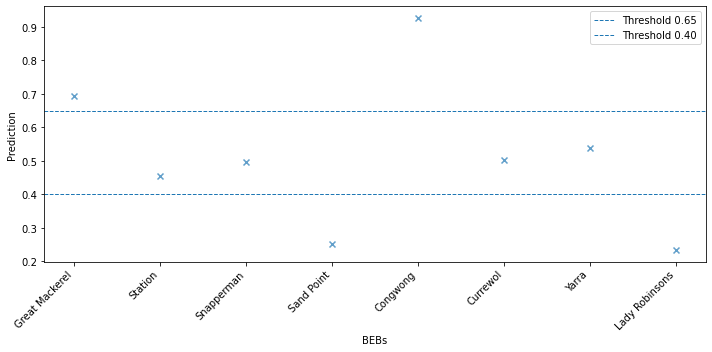

In [56]:
import matplotlib.pyplot as plt  # <-- fix here

df_full["Prediction"] = Composite_Index  # make sure this aligns in length

plt.figure(figsize=(10,5))
plt.scatter(df_full["BEBs"], df_full["Prediction"], alpha=0.7, marker='x')
ax = plt.gca()

plt.xticks(rotation=45, ha='right')
ax.set_xlabel("BEBs")
ax.set_ylabel("Prediction")

ax.axhline(0.65, linestyle='--', linewidth=1, label='Threshold 0.65')
ax.axhline(0.40, linestyle='--', linewidth=1, label='Threshold 0.40')  # fixed label

plt.tight_layout()
plt.legend()  # to show the threshold lines
plt.show()


C:\Users\mgaz4900\AppData\Local\Temp\ipykernel_14496\652808909.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x, rotation=45, fontsize=12)
C:\Users\mgaz4900\AppData\Local\Temp\ipykernel_14496\652808909.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(x,rotation=90)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


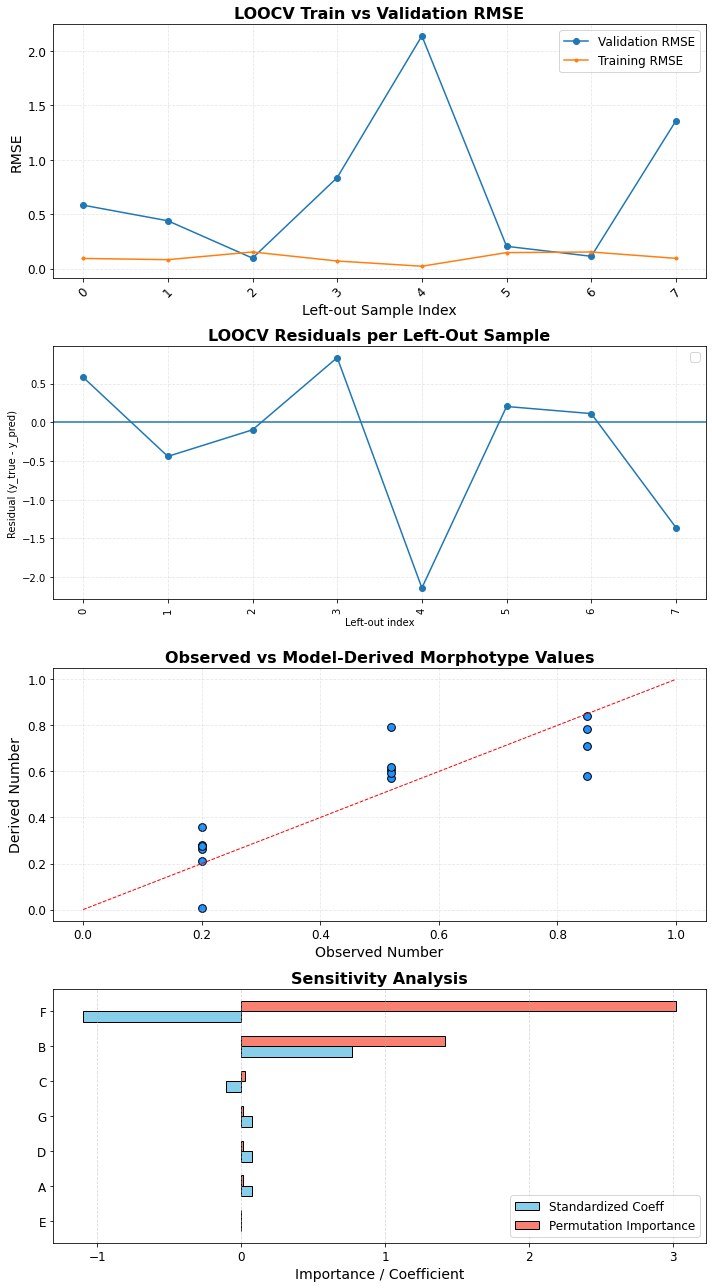

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_obs = pd.read_csv("validated_plot.csv")

# ------------------------------
# 1. LOOCV RMSE plot function
# ------------------------------
def plot_val_mse_per_run_sub(results_df, ax):
    df = results_df.sort_index()
    x = df.index.astype(str)
    val_rmse = df["val_rmse"].to_numpy()
    train_rmse = df["train_rmse"].to_numpy()
    ax.plot(x, val_rmse, marker="o", linewidth=1.5, label="Validation RMSE")
    ax.plot(x, train_rmse, marker=".", linewidth=1.5, label="Training RMSE")
    ax.set_xlabel("Left-out Sample Index", fontsize=14)
    ax.set_ylabel("RMSE", fontsize=14)
    ax.set_title("LOOCV Train vs Validation RMSE", fontsize=16, weight='bold')
    ax.set_xticklabels(x, rotation=45, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=12)

def plot_residuals_per_run(results_df, ax):
    """Residuals (y_true - y_pred) per left-out index."""
    df = results_df.sort_index()
    x = df.index.astype(str)
    resid = (df["y_true"] - df["y_pred"]).to_numpy()
    ax.plot(x, resid, marker="o")
    ax.axhline(0)
    ax.set_xticklabels(x,rotation=90)
    ax.set_xlabel("Left-out index")
    ax.set_ylabel("Residual (y_true - y_pred)")
    ax.set_title("LOOCV Residuals per Left-Out Sample", fontsize=16, weight='bold')
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(fontsize=12)
    
# ------------------------------
# 3. Observed vs Derived plot function
# ------------------------------
def plot_obs_vs_derived_sub(df_obs, ax):
    x = df_obs['Observed Number']
    y = df_obs['Derived Number']
    ax.scatter(x, y, color='dodgerblue', edgecolor='black', s=60)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)  # 1:1 line
    ax.set_xlabel("Observed Number", fontsize=14)
    ax.set_ylabel("Derived Number", fontsize=14)
    ax.set_title("Observed vs Model-Derived Morphotype Values", fontsize=16, weight='bold')
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.3)
    

# ------------------------------
# 2. Sensitivity Analysis plot function
# ------------------------------
def plot_sensitivity_analysis(importance_df, ax):
    importance_df = importance_df.sort_values("Permutation_Importance", ascending=True)
    y_pos = np.arange(len(importance_df))
    
    ax.barh(y_pos - 0.15, importance_df["Regression_Coeff"], height=0.3,
            color='skyblue', edgecolor='black', label="Standardized Coeff")
    ax.barh(y_pos + 0.15, importance_df["Permutation_Importance"], height=0.3,
            color='salmon', edgecolor='black', label="Permutation Importance")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(importance_df.index, fontsize=12)
    ax.set_xlabel("Importance / Coefficient", fontsize=14)
    ax.set_title("Sensitivity Analysis", fontsize=16, weight='bold')
    ax.tick_params(axis='x', labelsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.legend(fontsize=12)
    

# ------------------------------
# 4. Create combined figure with 3 vertical subplots
# ------------------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 18))

plot_val_mse_per_run_sub(results_df, ax=axes[0])
plot_obs_vs_derived_sub(df_obs, ax=axes[2])
plot_sensitivity_analysis(importance_df, ax=axes[3])
plot_residuals_per_run(results_df, ax=axes[1])

plt.tight_layout()
plt.show()
